# Drift Chamber Geant4 Sim Data Analysis

In [2]:
import numpy as np
import matplotlib.pyplot as plt 
from mpl_toolkits import mplot3d
import pandas as pd
import random

from matplotlib.lines import Line2D
from matplotlib.patches import Annulus
import matplotlib.colors as mcolors
import matplotlib.colorbar as mcolorbar

#%matplotlib widget

## Import Data

In [4]:
def organize_df(df, droplist):
    for name in droplist:
        
        # split formatted str to list of strs
        str_list = df[name].str.split('|').str[:-1]

        # convert strs to floats
        df[name] = str_list.apply(lambda x: [float(i) for i in x] if isinstance(x, list) else x)

    cols = df.filter(like=f"{droplist[0]}").columns        # get column with name droplist[0]
    nan_indices = df.index[~df[cols].notna().any(axis=1)]   # find indices with nan val

    df = df.drop(nan_indices)                               # drop row if it has nan val
    
    return df


In [5]:
# Get gas hit data
events_df = pd.read_csv(f'csv/hits/event_action_data.csv')
events_df = organize_df(events_df, ['energies', 'hitx', 'hity', 'hitz'])

# Get initial step data
steps_df = pd.read_csv(f'csv/hits/init_step_data.csv')

# Get multiple scattering data
eepos_df = pd.read_csv(f'csv/hits/entry_exit_data.csv')

# Get gas layer data
layer_df = pd.read_csv(f'csv/hits/layered_edep_data.csv')
layer_df = organize_df(layer_df, ["entry_x", "entry_y", "entry_z", "exit_x", "exit_y", "exit_z", "edep"])

# Get radii of gas layers
radii_df = pd.read_csv(f'csv/hits/layer_radius.csv')


In [6]:
def data_for_cylinder(r_outer, r_inner, res, height):
    theta = np.linspace(0, 2 * np.pi, res)
    z = np.linspace(-height, height, res)
    theta_grid, z_grid = np.meshgrid(theta, z)
    
    x_grid = r_outer * np.cos(theta_grid)
    y_grid = r_outer * np.sin(theta_grid)
    
    return x_grid, y_grid, z_grid

## Energy loss

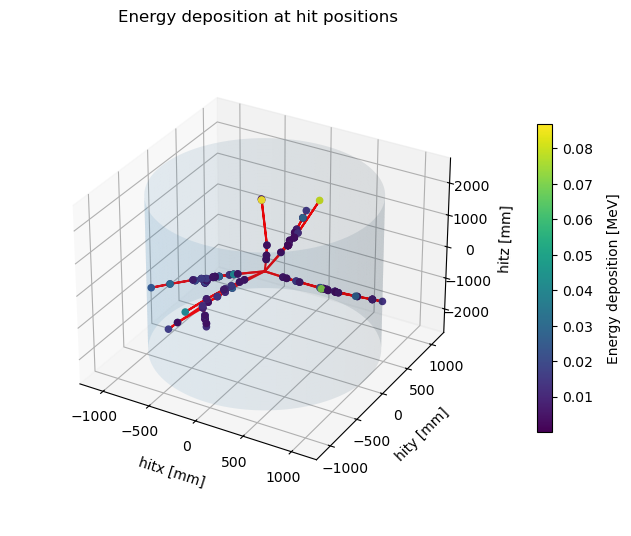

In [8]:
def plot_Edep_per_hit(df, num):
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    hitx = []
    hity = []
    hitz = []
    energies = []
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(0, num):
        try:      cur_row = df.loc[i]
        except:   continue
    
        energies += cur_row['energies']
        x = cur_row['hitx']
        y = cur_row['hity']
        z = cur_row['hitz']
    
        ax.plot3D([0.]+x, [0.]+y, [0.]+z, 'red')
    
        hitx += x
        hity += y
        hitz += z
    
    img = ax.scatter(hitx, hity, hitz, c=energies, cmap='viridis', alpha=1.0)
    
    cbar = fig.colorbar(img, ax=ax, shrink=0.5, pad=0.05)
    cbar.set_label("Energy deposition [MeV]", labelpad=10)
    
    plt.title("Energy deposition at hit positions")
    ax.set_xlabel('hitx [mm]', labelpad=10)
    ax.set_ylabel('hity [mm]', labelpad=10)
    ax.set_zlabel('hitz [mm]', labelpad=10)


num_to_plot = 10
plot_Edep_per_hit(events_df, num_to_plot)

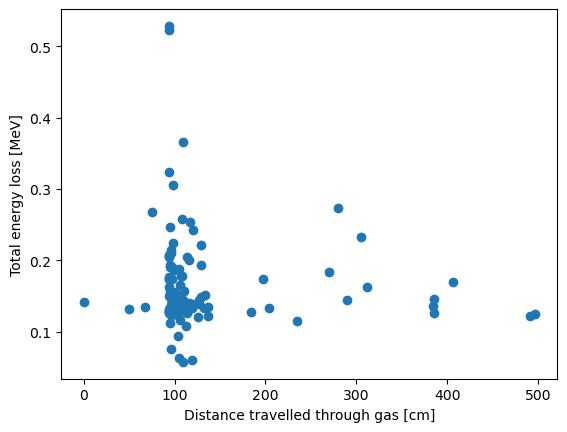

In [9]:
def plot_Eloss_over_dist(df1, df2):
    totE = []
    dist = []
    
    count = 0
    
    for i in range(len(events_df)):
        try:
            cur_event = df1.loc[i]
            cur_step = df2.loc[count]
        except:
            continue
    
        if not cur_event["num_hits"]: continue
        
        totE.append(sum([float(x) for x in cur_event['energies'][:-1]])) 
        dist.append(cur_step["tot_dist"])
        count += 1
    
    totE = np.array(totE)
    tot_dis = np.array(dist) * 0.1
    
    plt.scatter(tot_dis, totE)
    plt.xlabel("Distance travelled through gas [cm]")
    plt.ylabel("Total energy loss [MeV]")

    return tot_dis

tot_dis = plot_Eloss_over_dist(events_df, steps_df)

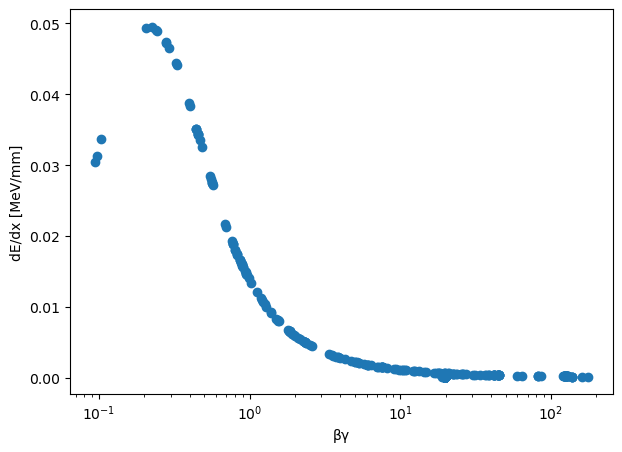

In [59]:
rest_mass = 105.6583715 #MeV
density =  4.75079e15 * 0.000001 #g /mm3

'''
fig2 = plt.figure(figsize=(7,5))
plt.scatter(steps_df["beta_gamma"], steps_df["dEdx"] / density)
plt.xlabel("βγ")
plt.ylabel("dE/dx [MeV mm$^2$/g]")
#'''

fig = plt.figure(figsize=(7,5))
plt.scatter(steps_df["beta_gamma"], steps_df["dEdx"])
plt.xlabel("βγ")
plt.ylabel("dE/dx [MeV/mm]")

plt.xscale('log')
#plt.yscale('log')

## Energy deposition in gas layers

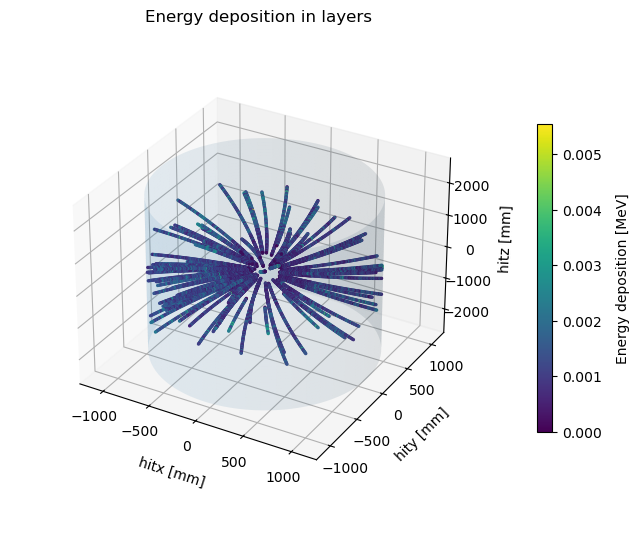

In [49]:
def plot_layered_beams(df, n):
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)

    x = []
    y = []
    z = []
    edep = []
    
    for i in range(0, n):
        try:     cur_df = df.loc[i]
        except:  continue

        #FIX THIS PROBLEM!!!
        cur_x = cur_df["entry_x"]
        cur_edep = cur_df["edep"]
        min_len = len(cur_x) - len(cur_edep)
        
        x += cur_x
        y += cur_df["entry_y"]
        z += cur_df["entry_z"]

        if min_len:
            edep += cur_edep[:-min_len]
        else:
            edep += cur_edep[:]
            
    img = ax.scatter(x, y, z, s=2, c=edep, cmap='viridis', alpha=1.0)
        
    cbar = fig.colorbar(img, ax=ax, shrink=0.5, pad=0.05)
    cbar.set_label("Energy deposition [MeV]", labelpad=10)

    plt.title("Energy deposition in layers")
    ax.set_xlabel('hitx [mm]', labelpad=10)
    ax.set_ylabel('hity [mm]', labelpad=10)
    ax.set_zlabel('hitz [mm]', labelpad=10)

num_to_plot = 100
plot_layered_beams(layer_df, num_to_plot)

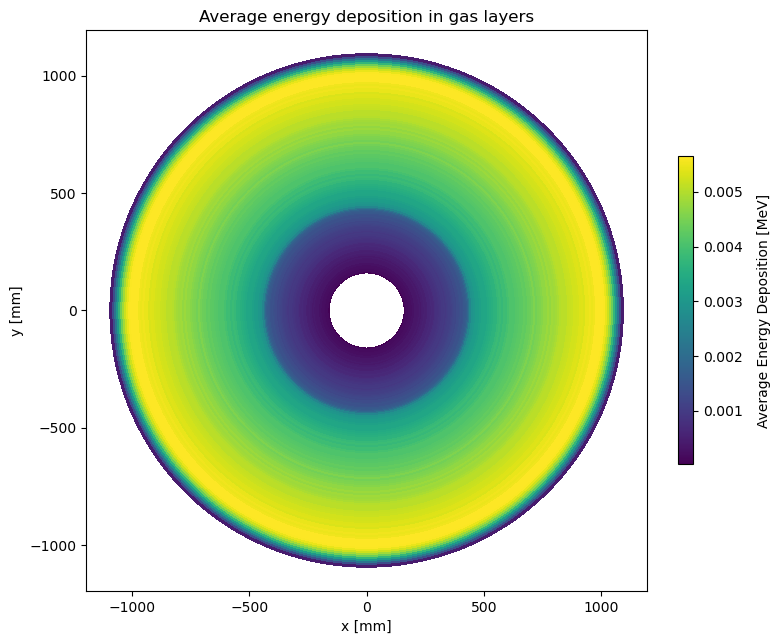

In [13]:
def get_avg_edep_in_layer(r_inner, r_outer, df):
    tot_edep = 0
    
    for idx, cur_df in df.iterrows():
        energies = cur_df["edep"]
        
        for j in range(len(energies)):
            entry_r = np.sqrt( cur_df["entry_x"][j] ** 2 + cur_df["entry_y"][j] ** 2 )
            exit_r = np.sqrt( cur_df["exit_x"][j] ** 2 + cur_df["exit_y"][j] ** 2 )
            
            if entry_r > r_inner and exit_r < r_outer:
                tot_edep += energies[j]
                
    return tot_edep / len(df) if len(df) > 0 else 0


def plot_layer_overview(rad_df, df):
    fig, ax = plt.subplots(figsize=(8, 8))
    energies = []

    for idx, row in rad_df.iterrows():
        energies.append(get_avg_edep_in_layer(row["r1"], row["r2"], df))

    norm = mcolors.Normalize(vmin=min(energies), vmax=max(energies))
    cmap = plt.get_cmap("viridis")

    for idx, row in rad_df.iterrows():
        r1 = row["r1"]
        r2 = row["r2"]
        colour = cmap(norm(energies[idx]))
        ring = Annulus(xy=(0, 0), r=r2, width=r2 - r1, facecolor=colour)
        ring.set_antialiased(False)
        ax.add_patch(ring)

    max_r = rad_df["r2"].max()
    ax.set_xlim(-(max_r + 100), max_r + 100)
    ax.set_ylim(-(max_r + 100), max_r + 100)
    ax.set_aspect("equal")

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]") 
    ax.set_title("Average energy deposition in gas layers")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, shrink=0.5, pad=0.05)
    cbar.set_label("Average Energy Deposition [MeV]", labelpad=10)

    return energies

energies = plot_layer_overview(radii_df, layer_df)

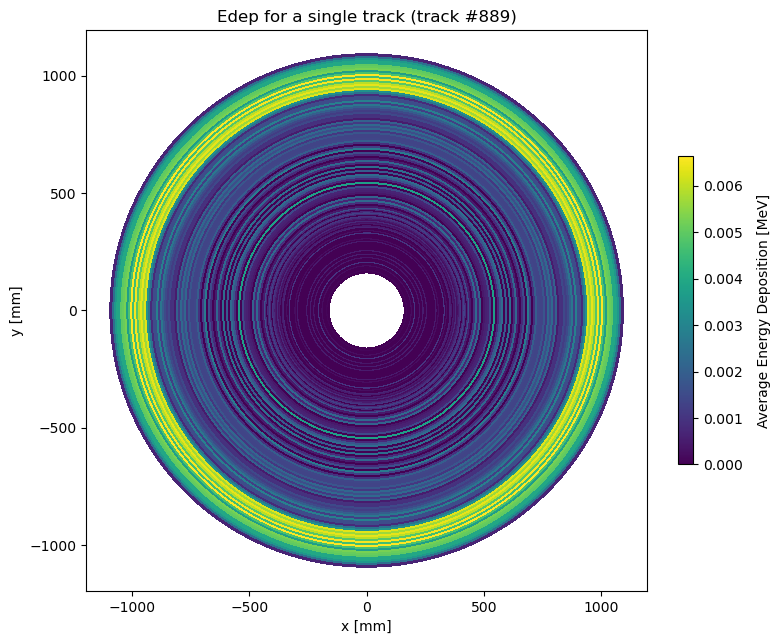

In [14]:
def get_edep_in_layer(r_inner, r_outer, df, ran_num):
    tot_edep = 0

    cur_df = df.iloc[ran_num]
    energies = cur_df["edep"]
        
    for j in range(len(energies)):
        entry_r = np.sqrt( cur_df["entry_x"][j] ** 2 + cur_df["entry_y"][j] ** 2 )
        exit_r = np.sqrt( cur_df["exit_x"][j] ** 2 + cur_df["exit_y"][j] ** 2 )
            
        if entry_r > r_inner and exit_r < r_outer:
            tot_edep += energies[j]
                
    return tot_edep

def plot_onetrack_layer(rad_df, df, ran_num):
    fig, ax = plt.subplots(figsize=(8, 8))
    energies = []

    for idx, row in rad_df.iterrows():
        energies.append(get_edep_in_layer(row["r1"], row["r2"], df, ran_num))

    norm = mcolors.Normalize(vmin=min(energies), vmax=max(energies))
    cmap = plt.get_cmap("viridis")

    for idx, row in rad_df.iterrows():
        r1 = row["r1"]
        r2 = row["r2"]
        colour = cmap(norm(energies[idx]))
        ring = Annulus(xy=(0, 0), r=r2, width=r2 - r1, facecolor=colour)
        ring.set_antialiased(False)
        ax.add_patch(ring)

    max_r = rad_df["r2"].max()
    ax.set_xlim(-(max_r + 100), max_r + 100)
    ax.set_ylim(-(max_r + 100), max_r + 100)
    ax.set_aspect("equal")

    ax.set_xlabel("x [mm]")
    ax.set_ylabel("y [mm]") 
    ax.set_title(f"Edep for a single track (track #{ran_num})")

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])  
    cbar = fig.colorbar(sm, ax=ax, fraction=0.046, shrink=0.5, pad=0.05)
    cbar.set_label("Average Energy Deposition [MeV]", labelpad=10)

    return energies

ran_num = random.randint(0, len(layer_df) - 1)
single_energies = plot_onetrack_layer(radii_df, layer_df, ran_num)

Text(0.5, 1.0, 'Edep for a single track (track #889)')

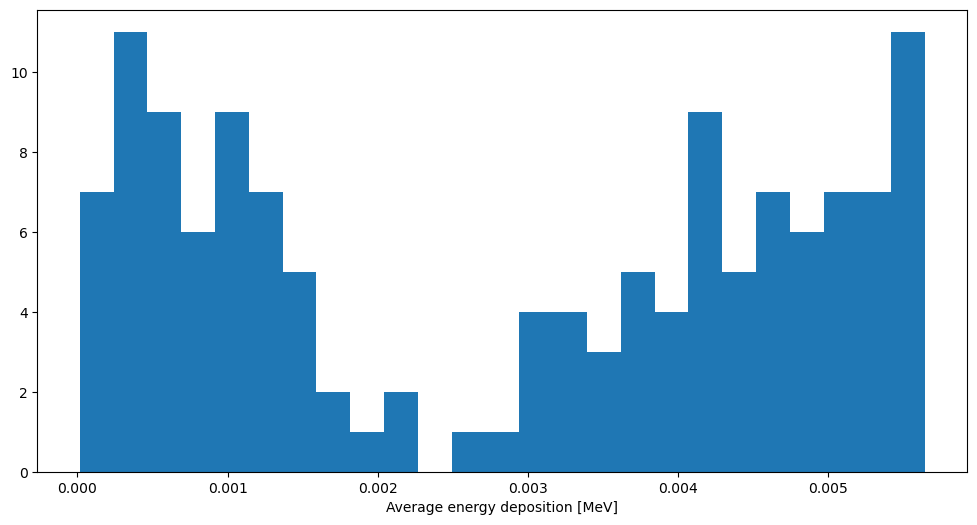

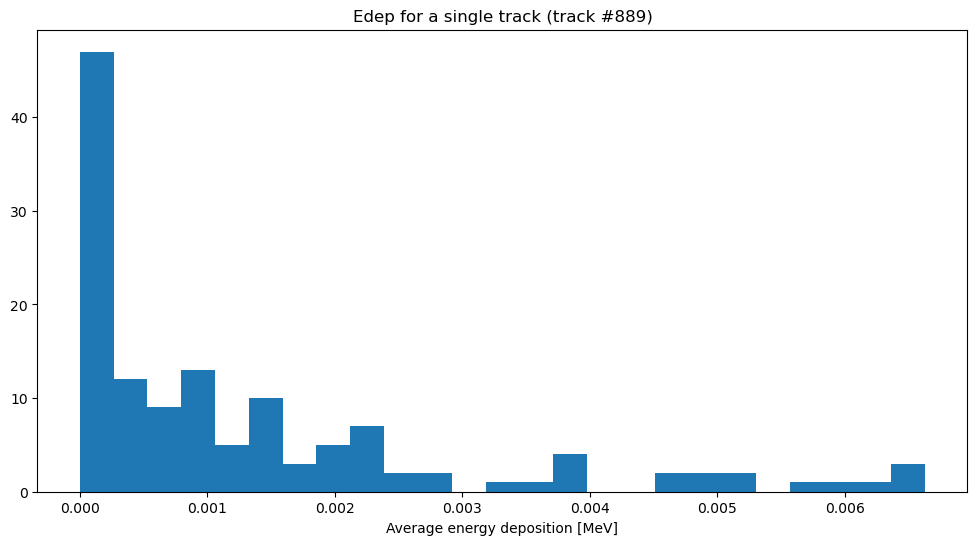

In [45]:
plt.figure(figsize=(12,6))
plt.hist(energies, bins=25)
plt.xlabel("Average energy deposition [MeV]")

plt.figure(figsize=(12,6))
plt.hist(single_energies, bins=25)
plt.xlabel("Average energy deposition [MeV]")
plt.title(f"Edep for a single track (track #{ran_num})")

## Tracks and Multiple Scattering

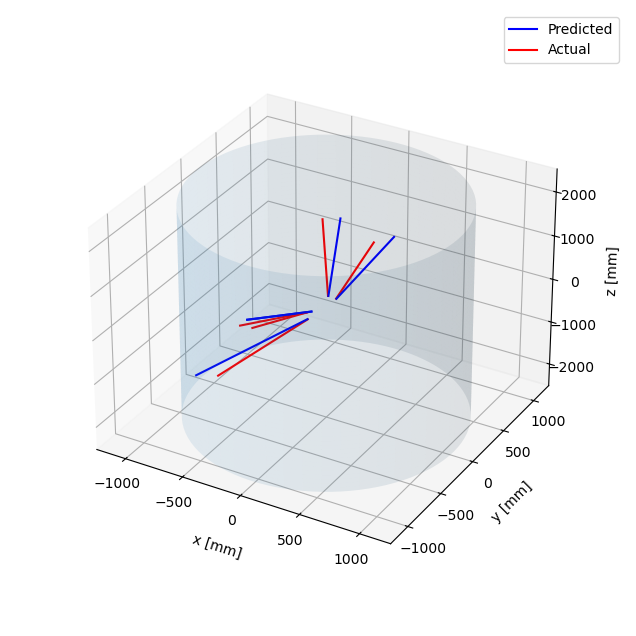

In [17]:
def plot_act_and_pred(df, n):
    '''Plot a linear version of the first n tracks using their start and end points'''
    
    fig = plt.figure(figsize=(8, 8))
    ax = fig.add_subplot(projection='3d')
    ax.set_box_aspect(None, zoom=0.85)
    
    Xc,Yc,Zc = data_for_cylinder(1096, 160, 100, 2416.9)
    ax.plot_surface(Xc, Yc, Zc, alpha=0.1)
    
    for i in range(0, n):
        curdf = df.loc[i]
    
        ax.plot3D([curdf["actx_ent"], curdf["actx_exit"]], \
                  [curdf["acty_ent"], curdf["acty_exit"]], \
                  [curdf["actz_ent"], curdf["actz_exit"]], 'red')

        ax.plot3D([curdf["predx_ent"], curdf["predx_exit"]], \
                      [curdf["predy_ent"], curdf["predy_exit"]], \
                      [curdf["predz_ent"], curdf["predz_exit"]], 'blue')
    
    ax.set_xlabel('x [mm]', labelpad=10)
    ax.set_ylabel('y [mm]', labelpad=10)
    ax.set_zlabel('z [mm]', labelpad=10)

    # Add legend
    blue_line = Line2D([1, 4], [2, 5], color='blue', label="Predicted")
    red_line = Line2D([1, 4], [2, 5], color='red', label="Actual")
    plt.legend(handles=[blue_line, red_line])
    
num_to_plot = 5
plot_act_and_pred(eepos_df, num_to_plot)

In [18]:
def get_avg_scattering(df):
    sum_dist = 0
    
    for i in range(0, len(df)):
        curdf = df.loc[i]
        sum_dist += np.sqrt( (curdf["actx_ent"]-curdf["predx_ent"])**2 +\
                             (curdf["acty_ent"]-curdf["predy_ent"])**2 +\
                             (curdf["actz_ent"]-curdf["predz_ent"])**2 )

    sum_dist /= len(df)
    
    print(f'Average distance of scattering = {sum_dist:.4f} mm')
    return sum_dist

get_avg_scattering(eepos_df)

Average distance of scattering = 133.7457 mm


133.74572558077466